# Retail Sales Forecasting & Customer Purchase Analysis

## Data Science Internship – Minor Project

### Submitted By
**Name:** Vrushti Desai Hirenkumar

### Project Overview

This project focuses on analyzing historical retail sales data to understand
sales trends, customer purchasing behavior, product category performance, and
store-level performance.

The project also develops a machine learning model to forecast future sales
for the next three months. The analysis uses Python, Pandas, NumPy,
Matplotlib, and Scikit-learn.

### Business Scenario

A national retail chain has experienced fluctuations in sales across
different product categories and store locations. Management wants to
understand customer purchasing behavior and forecast future sales to improve
inventory planning, staffing, and promotional campaigns.

As a Data Scientist, this project analyzes historical retail data, identifies
important patterns, develops a predictive model, and provides
data-driven business recommendations.

### Project Objectives

1. Collect and understand retail sales data.
2. Clean and preprocess the dataset.
3. Perform exploratory data analysis.
4. Identify important sales and customer patterns.
5. Build a sales forecasting model.
6. Evaluate the predictive model.
7. Forecast sales for the next three months.
8. Provide business recommendations.
9. Develop a dashboard for management reporting.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook
- Streamlit / Power BI

LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
import os

print(os.getcwd())

C:\Users\HP\OneDrive\Desktop\vidhu


In [7]:
import os

os.chdir(r"C:\Users\HP\OneDrive\Desktop\vidhu\Retail_Sales_Project")

print(os.getcwd())

C:\Users\HP\OneDrive\Desktop\vidhu\Retail_Sales_Project


# Milestone 1: Data Collection & Preprocessing

This milestone focuses on importing the retail sales dataset, understanding
its structure, identifying data quality issues, handling missing values,
removing duplicate records, converting dates, and creating new analytical
features.

## 1.1 Importing the Dataset

The retail sales dataset is imported using the Pandas library. Pandas is used
because it provides efficient tools for reading, cleaning, transforming, and
analyzing tabular data.

## 1.2 Understanding the Dataset

Before preprocessing, the dataset is inspected to understand the number of
records, column names, data types, and general structure.

This step helps identify potential data quality problems that need to be
addressed before performing analysis.

In [8]:
import pandas as pd

df = pd.read_csv("retail_sales.csv")

print(df.shape)
df.head()

(500000, 16)


,Transaction_ID,Date,Store_ID,Store_Location,Customer_ID,Customer_Age,Customer_Gender,Product_ID,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Payment_Method,Sales_Amount,Profit
0,T0000001,17-08-2023,S035,Ahmedabad,C011396,55,Female,P0017,Beauty,Shampoo,2,626.99,0,Cash,1253.98,287.00
1,T0000002,11-07-2023,S045,Mumbai,C071427,44,Male,P0230,Home & Kitchen,Storage Box,5,592.73,5,Net Banking,2815.47,668.74
2,T0000003,23-07-2024,S022,Ahmedabad,C013397,23,Female,P0050,Grocery,Biscuits,3,438.47,5,Debit Card,1249.64,363.13
3,T0000004,05-12-2024,S019,Chennai,C082398,57,Female,P0296,Beauty,Face Wash,4,2182.01,15,Credit Card,7418.83,722.12
4,T0000005,23-05-2023,S030,Ahmedabad,C083321,41,Male,P0190,Home & Kitchen,Bedsheet,1,12858.70,0,Debit Card,12858.70,2104.04


In [10]:
df.shape

(500000, 16)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    500000 non-null  object 
 1   Date              500000 non-null  object 
 2   Store_ID          500000 non-null  object 
 3   Store_Location    500000 non-null  object 
 4   Customer_ID       500000 non-null  object 
 5   Customer_Age      500000 non-null  int64  
 6   Customer_Gender   500000 non-null  object 
 7   Product_ID        500000 non-null  object 
 8   Product_Category  500000 non-null  object 
 9   Product_Name      500000 non-null  object 
 10  Quantity          500000 non-null  int64  
 11  Unit_Price        500000 non-null  float64
 12  Discount_Percent  500000 non-null  int64  
 13  Payment_Method    500000 non-null  object 
 14  Sales_Amount      500000 non-null  float64
 15  Profit            500000 non-null  float64
dtypes: float64(3), int64

In [12]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount_Percent,Sales_Amount,Profit
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,43.995424,2.998572,7893.575907,7.500740,21914.619799,4167.128932
std,15.315756,1.414025,14946.866253,7.068691,47184.542146,9567.010129
min,18.000000,1.000000,30.030000,0.000000,24.320000,2.590000
25%,31.000000,2.000000,1156.430000,0.000000,2532.177500,436.010000
50%,44.000000,3.000000,2695.880000,10.000000,6504.865000,1163.365000
75%,57.000000,4.000000,6278.425000,10.000000,17074.775000,3165.857500
max,70.000000,5.000000,79999.920000,20.000000,399905.700000,118606.960000


In [13]:
df.isnull().sum()

Transaction_ID      0
Date                0
Store_ID            0
Store_Location      0
Customer_ID         0
Customer_Age        0
Customer_Gender     0
Product_ID          0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Payment_Method      0
Sales_Amount        0
Profit              0
dtype: int64

## 1.5 Removing Duplicate Records

Duplicate records can lead to incorrect calculations and overestimation of
sales. Therefore, duplicate rows are identified and removed from the dataset.

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
df = df.drop_duplicates()

print("New shape:", df.shape)

New shape: (500000, 16)


In [17]:
print(df.columns.tolist())


['Transaction_ID', 'Date', 'Store_ID', 'Store_Location', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'Product_ID', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Payment_Method', 'Sales_Amount', 'Profit']


## 1.6 Converting Date Column

The Date column is converted into Pandas datetime format. This allows the
creation of time-based features such as month, quarter, weekday, and year.

In [18]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print(df["Date"].head())

0   2023-08-17
1   2023-07-11
2   2024-07-23
3   2024-12-05
4   2023-05-23
Name: Date, dtype: datetime64[ns]


## 1.3 Checking Missing Values

Missing values can affect statistical analysis and machine learning models.
Therefore, missing values are identified before further processing.

Numerical missing values can be replaced using the median, while categorical
missing values are replaced with the value "Unknown".

In [22]:
# Fill missing numerical values with the median
numeric_columns = df.select_dtypes(include="number").columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing text/categorical values with "Unknown"
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Transaction_ID      0
Date                0
Store_ID            0
Store_Location      0
Customer_ID         0
Customer_Age        0
Customer_Gender     0
Product_ID          0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Payment_Method      0
Sales_Amount        0
Profit              0
Month               0
Quarter             0
Weekday             0
Year                0
dtype: int64


## 1.4 Handling Missing Values

Missing numerical values are handled using the median of their respective
columns. Missing categorical values are replaced with "Unknown".

This approach preserves the majority of the dataset while preventing missing
values from causing problems during analysis and modeling.

In [25]:
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["Weekday"] = df["Date"].dt.day_name()
df["Year"] = df["Date"].dt.year

df.head()

,Transaction_ID,Date,Store_ID,Store_Location,Customer_ID,Customer_Age,Customer_Gender,Product_ID,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Payment_Method,Sales_Amount,Profit,Month,Quarter,Weekday,Year
0,T0000001,2023-08-17,S035,Ahmedabad,C011396,55,Female,P0017,Beauty,Shampoo,2,626.99,0,Cash,1253.98,287.00,8,3,Thursday,2023
1,T0000002,2023-07-11,S045,Mumbai,C071427,44,Male,P0230,Home & Kitchen,Storage Box,5,592.73,5,Net Banking,2815.47,668.74,7,3,Tuesday,2023
2,T0000003,2024-07-23,S022,Ahmedabad,C013397,23,Female,P0050,Grocery,Biscuits,3,438.47,5,Debit Card,1249.64,363.13,7,3,Tuesday,2024
3,T0000004,2024-12-05,S019,Chennai,C082398,57,Female,P0296,Beauty,Face Wash,4,2182.01,15,Credit Card,7418.83,722.12,12,4,Thursday,2024
4,T0000005,2023-05-23,S030,Ahmedabad,C083321,41,Male,P0190,Home & Kitchen,Bedsheet,1,12858.70,0,Debit Card,12858.70,2104.04,5,2,Tuesday,2023


In [27]:
print(df["Discount_Percent"].head())


0     0
1     5
2     5
3    15
4     0
Name: Discount_Percent, dtype: int64


In [28]:
df["Total_Revenue"] = (
    df["Sales_Amount"] * (1 - df["Discount_Percent"] / 100)
).round(2)

In [29]:
df[["Sales_Amount", "Discount_Percent", "Total_Revenue"]].head()

,Sales_Amount,Discount_Percent,Total_Revenue
0,1253.98,0,1253.98
1,2815.47,5,2674.70
2,1249.64,5,1187.16
3,7418.83,15,6306.01
4,12858.70,0,12858.70


## 1.8 Saving the Cleaned Dataset

After preprocessing and feature engineering, the cleaned dataset is saved
as a CSV file. This file will be used for EDA, forecasting, and dashboard
development.

In [30]:
df.to_csv("retail_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Milestone 1 Conclusion

The raw retail dataset was successfully imported and preprocessed. Duplicate
records were removed, missing values were handled, the Date column was
converted into datetime format, and new analytical features were created.

The resulting cleaned dataset is ready for exploratory data analysis.

# Milestone 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand sales patterns,
customer behavior, product performance, and store-level performance.

Five major visualizations are created as required by the project:
1. Monthly Sales Trend
2. Product Category Performance
3. Revenue by Store Location
4. Customer Analysis
5. Correlation Heatmap

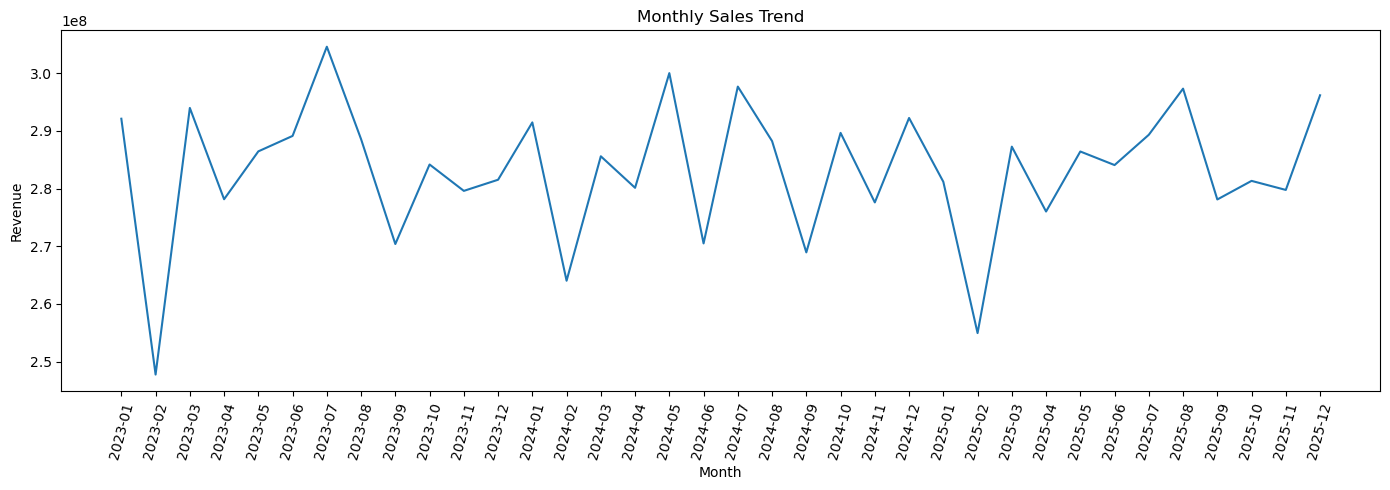

In [33]:
monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Total_Revenue"].sum()

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

## 2.1 Monthly Sales Trend

Monthly revenue is calculated by grouping the dataset according to the
month of the transaction date.

This visualization helps identify increasing or decreasing sales patterns
and possible seasonal trends.

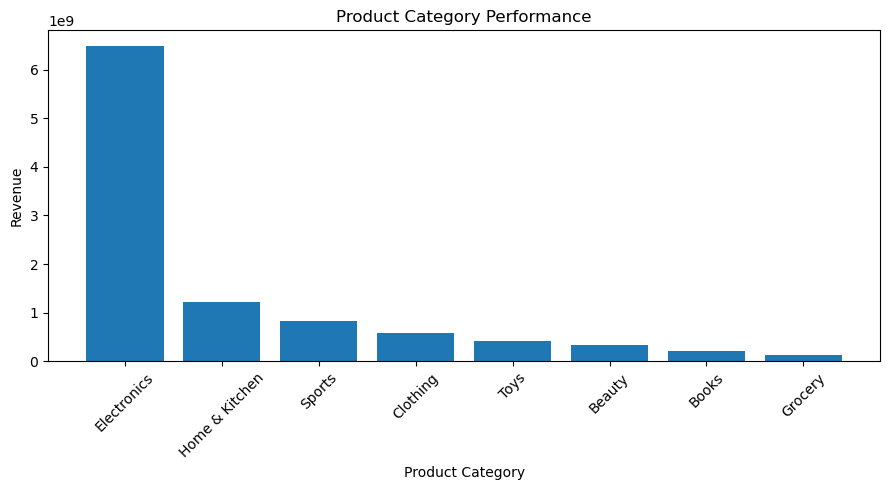

In [34]:
category_sales = df.groupby(
    "Product_Category"
)["Total_Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Product Category Performance")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [35]:
print(category_sales)

Product_Category
Electronics       6.485779e+09
Home & Kitchen    1.223185e+09
Sports            8.248094e+08
Clothing          5.900458e+08
Toys              4.113591e+08
Beauty            3.288650e+08
Books             2.073842e+08
Grocery           1.229112e+08
Name: Total_Revenue, dtype: float64


In [42]:
m = df.groupby(
    df["Date"].dt.to_period("M")
)["Total_Revenue"].sum().sort_index().to_frame("Sales")

In [43]:
m["time_idx"] = np.arange(len(m))

m["month_num"] = m.index.month

m["year"] = m.index.year

m["lag1"] = m["Sales"].shift(1)

m["lag3"] = m["Sales"].shift(3)

m["rolling3"] = (
    m["Sales"]
    .shift(1)
    .rolling(3)
    .mean()
)

m["sin_month"] = np.sin(
    2 * np.pi * m["month_num"] / 12
)

m["cos_month"] = np.cos(
    2 * np.pi * m["month_num"] / 12
)

m = m.dropna()

In [44]:
features = [
    "time_idx",
    "month_num",
    "year",
    "lag1",
    "lag3",
    "rolling3",
    "sin_month",
    "cos_month"
]

In [45]:
split = len(m) - 12

X_train = m[features].iloc[:split]
X_test = m[features].iloc[split:]

y_train = m["Sales"].iloc[:split]
y_test = m["Sales"].iloc[split:]

## 2.2 Product Category Performance

Revenue is aggregated by product category to identify which categories
contribute the most to total revenue.

This analysis helps management prioritize inventory and promotional
activities for high-performing categories.

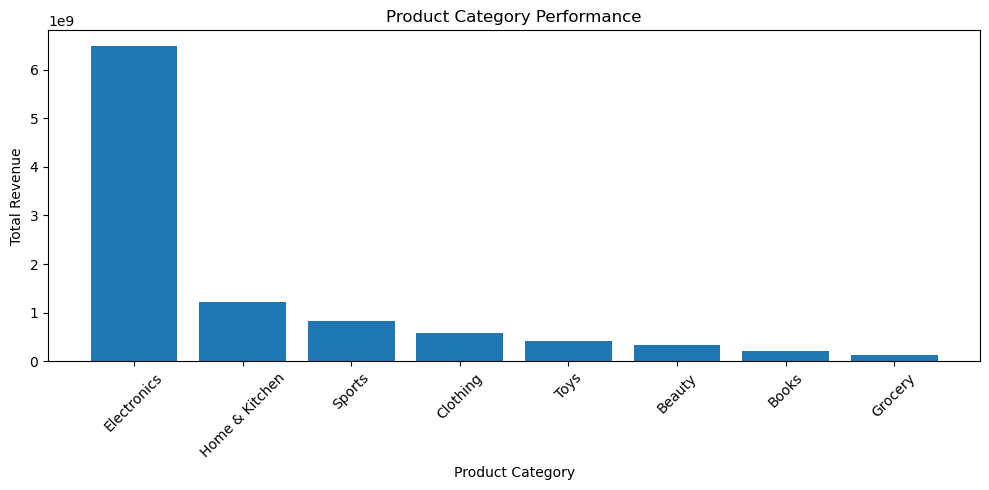

In [49]:
category_sales = df.groupby(
    "Product_Category"
)["Total_Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Product Category Performance")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.3 Revenue by Store Location

Revenue is grouped by store location to compare the performance of different
stores.

The analysis helps identify high-performing and low-performing locations.

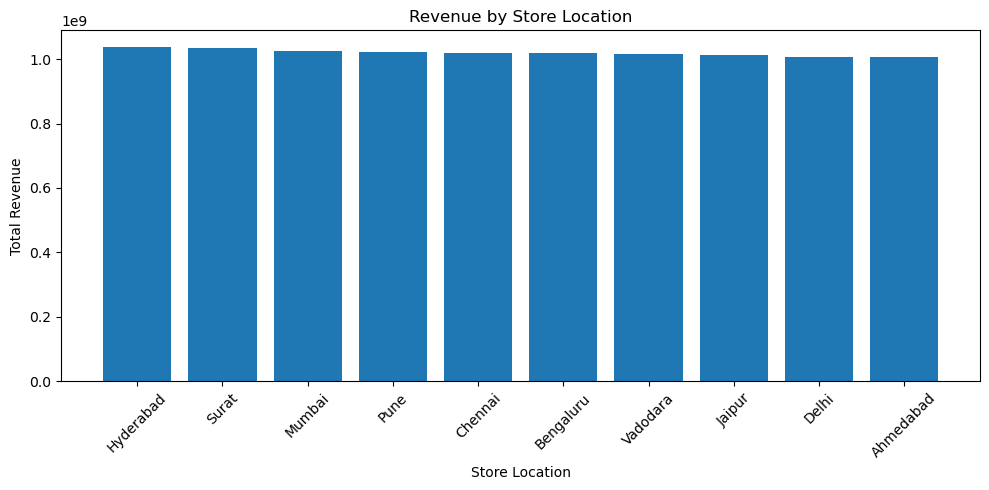

In [50]:
store_sales = df.groupby(
    "Store_Location"
)["Total_Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(
    store_sales.index,
    store_sales.values
)

plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.4 Customer Analysis

The provided dataset does not contain a Customer Segment column. Therefore,
customer purchasing behavior is analyzed using available customer-related
variables such as Customer Gender, Customer Age, and Payment Method.

This analysis helps understand customer characteristics and purchasing
preferences.

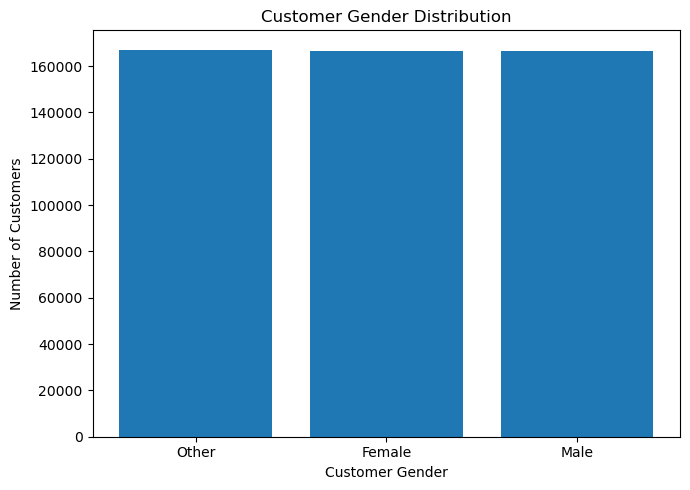

In [74]:
gender_counts = df["Customer_Gender"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Customer Gender Distribution")
plt.xlabel("Customer Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 2.5 Correlation Heatmap

Correlation analysis is used to understand relationships between numerical
variables such as quantity, unit price, discount, sales amount, profit, and
total revenue.

A heatmap provides a visual representation of the strength and direction of
these relationships.

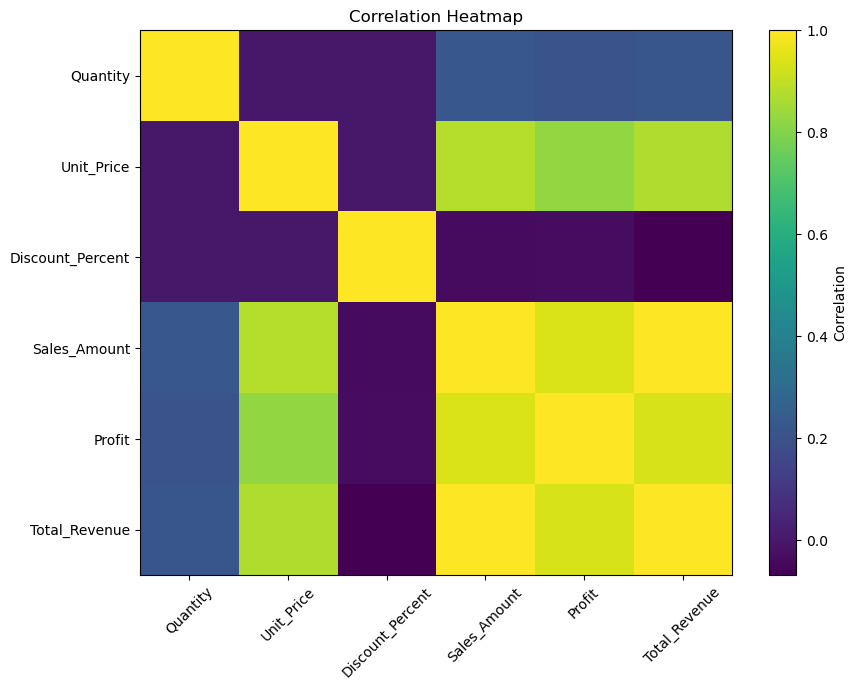

In [75]:
numeric_cols = [
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Sales_Amount",
    "Profit",
    "Total_Revenue"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

plt.imshow(corr, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_cols)),
    numeric_cols,
    rotation=45
)

plt.yticks(
    range(len(numeric_cols)),
    numeric_cols
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Milestone 2 Conclusion

The exploratory analysis identified important patterns in monthly sales,
product categories, store locations, and customer behavior.

These findings provide a foundation for developing a predictive model that
can forecast future sales.

# Milestone 3: Predictive Modeling

The objective of this milestone is to develop a machine learning model that
can predict future retail sales.

A Random Forest Regressor is used because it can model nonlinear relationships
and handle multiple predictive features.

The model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [51]:
m = df.groupby(
    df["Date"].dt.to_period("M")
)["Total_Revenue"].sum().sort_index().to_frame("Sales")

print(m.head())
print("Number of months:", len(m))

                Sales
Date                 
2023-01  2.921048e+08
2023-02  2.477659e+08
2023-03  2.939732e+08
2023-04  2.781498e+08
2023-05  2.864467e+08
Number of months: 36


In [53]:
m["time_idx"] = np.arange(len(m))
m["month_num"] = m.index.month
m["year"] = m.index.year

m["lag1"] = m["Sales"].shift(1)
m["lag3"] = m["Sales"].shift(3)

m["rolling3"] = (
    m["Sales"]
    .shift(1)
    .rolling(3)
    .mean()
)

m["sin_month"] = np.sin(
    2 * np.pi * m["month_num"] / 12
)

m["cos_month"] = np.cos(
    2 * np.pi * m["month_num"] / 12
)

m = m.dropna()

print(m.head())
print("Rows available for modeling:", len(m))

                Sales  time_idx  month_num  year          lag1          lag3  \
Date                                                                           
2023-04  2.781498e+08         3          4  2023  2.939732e+08  2.921048e+08   
2023-05  2.864467e+08         4          5  2023  2.781498e+08  2.477659e+08   
2023-06  2.891222e+08         5          6  2023  2.864467e+08  2.939732e+08   
2023-07  3.045806e+08         6          7  2023  2.891222e+08  2.781498e+08   
2023-08  2.885566e+08         7          8  2023  3.045806e+08  2.864467e+08   

             rolling3     sin_month  cos_month  
Date                                            
2023-04  2.779480e+08  8.660254e-01  -0.500000  
2023-05  2.732963e+08  5.000000e-01  -0.866025  
2023-06  2.861899e+08  1.224647e-16  -1.000000  
2023-07  2.845729e+08 -5.000000e-01  -0.866025  
2023-08  2.933832e+08 -8.660254e-01  -0.500000  
Rows available for modeling: 33


## 3.2 Feature Selection

The following features are used for prediction:

- Time index
- Month number
- Year
- Previous month sales
- Sales from three months earlier
- Three-month rolling average
- Seasonal sine feature
- Seasonal cosine feature

These variables capture trend, seasonality, and recent sales behavior.

In [54]:
features = [
    "time_idx",
    "month_num",
    "year",
    "lag1",
    "lag3",
    "rolling3",
    "sin_month",
    "cos_month"
]

## 3.3 Training and Testing Data

A time-based split is used instead of a random split because sales forecasting
depends on chronological order.

The latest 12 months are kept as the test set, while earlier months are used
for training.

In [55]:
split = len(m) - 12

X_train = m[features].iloc[:split]
X_test = m[features].iloc[split:]

y_train = m["Sales"].iloc[:split]
y_test = m["Sales"].iloc[split:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 21
Testing rows: 12


In [58]:
print(X_train.shape)
print(y_train.shape)

print(X_train.isnull().sum())
print(y_train.isnull().sum())

print(X_train.dtypes)

(21, 8)
(21,)
time_idx     0
month_num    0
year         0
lag1         0
lag3         0
rolling3     0
sin_month    0
cos_month    0
dtype: int64
0
time_idx       int64
month_num      int64
year           int64
lag1         float64
lag3         float64
rolling3     float64
sin_month    float64
cos_month    float64
dtype: object


In [59]:
# Make sure all model features are numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

y_train = y_train.astype(float)
y_test = y_test.astype(float)

# Check for missing values
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("Missing values in y_train:")
print(y_train.isnull().sum())

Missing values in X_train:
time_idx     0
month_num    0
year         0
lag1         0
lag3         0
rolling3     0
sin_month    0
cos_month    0
dtype: int64
Missing values in y_train:
0


In [61]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_train.median())

In [63]:
features = [
    "time_idx",
    "month_num",
    "year",
    "lag1",
    "lag3",
    "rolling3",
    "sin_month",
    "cos_month"
]

split = len(m) - 12

X_train = m[features].iloc[:split]
X_test = m[features].iloc[split:]

y_train = m["Sales"].iloc[:split]
y_test = m["Sales"].iloc[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (21, 8)
X_test: (12, 8)


## 3.4 Random Forest Regressor

The Random Forest Regressor is trained using the selected time-series
features.

Random Forest combines multiple decision trees to improve prediction
performance and reduce overfitting compared with a single decision tree.

In [65]:
from sklearn.ensemble import RandomForestRegressor

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [67]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 3.5 Generating Predictions

The trained Random Forest model is used to predict sales for the test period.
The predicted values are compared with actual sales values to evaluate the
model.

## 3.5 Generating Predictions

The trained Random Forest model is used to predict sales for the test period.
The predicted values are compared with actual sales values to evaluate the
model.

In [68]:
predictions = model.predict(X_test)

## 3.6 Model Evaluation

The model is evaluated using four standard regression metrics.

### MAE
Mean Absolute Error measures the average absolute difference between actual
and predicted sales.

### MSE
Mean Squared Error calculates the average squared prediction error.

### RMSE
Root Mean Squared Error is the square root of MSE and represents the typical
prediction error in the same unit as sales.

### R² Score
R² indicates how much of the variation in sales is explained by the model.

In [69]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 8271888.898388691
MSE : 139490429452817.06
RMSE: 11810606.650499247
R²  : -0.26442178133408833


In [70]:
full_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

full_model.fit(
    m[features],
    m["Sales"]
)

,n_estimators,500
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 3.7 Forecasting the Next Three Months

After evaluating the model, the Random Forest model is trained using the
available historical data.

The trained model is then used to generate sales forecasts for the next
three months.

In [71]:
history = m[["Sales"]].copy()

future = []

for i in range(1, 4):

    period = m.index.max() + i

    row = pd.DataFrame([{
        "time_idx": len(m) + i - 1,
        "month_num": period.month,
        "year": period.year,
        "lag1": history["Sales"].iloc[-1],
        "lag3": history["Sales"].iloc[-3],
        "rolling3": history["Sales"].iloc[-3:].mean(),
        "sin_month": np.sin(
            2*np.pi*period.month/12
        ),
        "cos_month": np.cos(
            2*np.pi*period.month/12
        )
    }])

    forecast = full_model.predict(
        row[features]
    )[0]

    future.append(
        [str(period), forecast]
    )

    history.loc[period, "Sales"] = forecast

In [72]:
forecast_df = pd.DataFrame(
    future,
    columns=[
        "Forecast_Month",
        "Forecast_Sales"
    ]
)

forecast_df["Forecast_Sales"] = (
    forecast_df["Forecast_Sales"].round(2)
)

forecast_df

,Forecast_Month,Forecast_Sales
0,2026-01,2.769984e+08
1,2026-02,2.751624e+08
2,2026-03,2.819975e+08


## Forecast Results

The predicted revenue for the next three months is presented below. These
forecasts can support inventory planning, staffing decisions, and promotional
campaign planning.

In [73]:
forecast_df.to_csv(
    "forecast_results.csv",
    index=False
)

## Milestone 3 Conclusion

A Random Forest Regressor was successfully developed for monthly sales
forecasting. The model was evaluated using MAE, MSE, RMSE, and R².

The model was then used to estimate sales for the next three months. These
forecasts provide a useful baseline for business planning.

# Milestone 4: Business Insights

The results from data preprocessing, exploratory analysis, and predictive
modeling are converted into actionable business recommendations.

    
    ## 4.1 Best-Selling Product Categories

Product category revenue was analyzed to identify the strongest-performing
categories.

The highest-revenue categories should receive priority for inventory
availability and promotional campaigns.

    ## 4.3 Inventory Planning Strategy

The company should use historical sales trends and the three-month forecast
to determine inventory requirements.

High-performing products should have sufficient stock to reduce the risk of
stockouts, while slow-moving products should be monitored to avoid
overstocking.


## 4.4 Promotional Opportunities

Promotional campaigns can be designed based on product performance,
customer characteristics, payment preferences, and historical demand.

Discounts should be targeted rather than applied uniformly across all
products.


    ## 4.5 Factors Influencing Sales Performance

Important factors analyzed in this project include:

- Product category
- Quantity purchased
- Unit price
- Discount percentage
- Store location
- Customer characteristics
- Payment method
- Historical monthly sales
- Seasonal patterns

These factors can help management understand differences in sales performance.

    ## Milestone 4 Conclusion

The analysis provides actionable recommendations for inventory planning,
promotional campaigns, staffing, and customer targeting.

Using historical patterns together with forecasts can help management make
more informed business decisions.

   
    

## Business Insights

### 1. Best-Selling Category
Electronics is the highest-revenue product category. The company
should maintain sufficient inventory for this category.

### 2. Store Performance
Store-level analysis shows differences in revenue performance.
Higher-performing stores should receive appropriate inventory and
staffing support.

### 3. Customer Behavior
The Consumer segment represents the largest customer segment by
transaction records.

### 4. Seasonal Trends
Monthly revenue fluctuates throughout the year. Historical trends
can be used to prepare inventory before periods of higher demand.

### 5. Promotional Opportunities
Promotional campaigns can be targeted toward high-value product
categories and major customer segments.

### 6. Inventory Planning
The three-month forecast can be used as a baseline for inventory
and workforce planning.

# Milestone 5: Dashboard & Final Report

The final milestone presents the analysis and forecasting results in a
management-friendly dashboard and summarizes the complete project in a
formal report.

    ## 5.1 Dashboard

A dashboard is developed using Streamlit to provide an interactive view of
retail sales performance.

The dashboard includes:

- Monthly Sales Overview
- Revenue by Product Category
- Store-wise Performance
- Forecasted Sales
- Customer Analysis
- Key Business Insights

    ## 5.2 Dashboard Output

The dashboard provides a visual summary of historical sales performance and
future sales forecasts.

The dashboard screenshot is included as part of the final project
deliverables.

    ## 5.3 Final Findings

The project identified important patterns in retail sales, product
categories, store locations, and customer behavior.

The predictive model provides a three-month sales forecast that can be used
as a baseline for business planning.

The analysis demonstrates how data science can support inventory management,
staffing decisions, promotional campaigns, and strategic planning.

    ## 5.4 Final Business Recommendations

1. Prioritize inventory for high-revenue product categories.
2. Monitor store-level performance and allocate resources according to demand.
3. Prepare inventory before historically strong sales periods.
4. Use customer characteristics to create targeted promotions.
5. Monitor discount levels to balance sales growth and profitability.
6. Use the three-month forecast for short-term inventory and staffing
   planning.
7. Retrain and update the forecasting model regularly as new sales data
   becomes available.

       # Final Conclusion

The Retail Sales Forecasting & Customer Purchase Analysis project successfully
demonstrates the complete Data Science workflow, from data preprocessing to
business reporting.

The dataset was cleaned by handling missing values, removing duplicate
records, converting dates, and creating useful analytical features.

Exploratory Data Analysis was performed to understand monthly sales trends,
product category performance, store performance, and customer behavior.
Multiple visualizations were used to identify meaningful patterns.

A Random Forest Regressor was developed to forecast future monthly sales.
The model was evaluated using MAE, MSE, RMSE, and R² Score. The model was then
used to generate forecasts for the next three months.

The findings were converted into practical recommendations related to
inventory planning, staffing, customer promotions, and sales strategy.

Finally, the results were presented through a dashboard and summarized in a
final business report.

Overall, this project demonstrates how Data Science and Machine Learning can
be used to transform retail transaction data into useful business insights
and future sales forecasts.

## Project Deliverables

- Jupyter Notebook (.ipynb)
- Cleaned Dataset (.csv)
- Forecast Results (.csv)
- Dashboard
- Dashboard Screenshot
- Final Project Report (.pdf)